<a href="https://colab.research.google.com/github/ZacharyJimmy/DataMining/blob/main/DataMiningCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import sklearn.metrics as metrics

In [ ]:
#Load Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Daily-1Raw_Daily_Imputed.csv to Daily-1Raw_Daily_Imputed (1).csv


,Date,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
0,12/29/1978,226,137.1,89668.53,110.7,910.95,865.79,37984.91,4549.32,2834.14,2768.15,7117547.34,2732.28,23463.63,12613005.94,6717.24,788332.07,28341.8,7030.64,946.87
1,1/1/1979,226,137.1,89668.53,110.7,910.95,865.79,37984.91,4549.32,2834.14,2768.15,7117547.34,2732.28,23463.63,12613005.94,6717.24,788332.07,28341.8,7030.64,946.87
2,1/2/1979,226.8,137.3,"43,164.90",111.5,263.7,359.6,"1,792.90",4549.32,2834.14,735.6,"138,160.50",851.3,"4,454.60",12613005.94,6717.24,"107,470.00",28341.8,194.6,193.6
3,1/3/1979,218.6,134,"43,717.90",108,264.4,365.9,"1,802.20",4549.32,2834.14,739.4,"138,877.00",855.7,"4,477.70",12613005.94,6717.24,"108,027.40",28341.8,192.2,193
4,1/4/1979,223.2,136.8,"43,674.90",110.7,264.1,366.4,"1,811.70",4549.32,2834.14,743.4,"139,616.30",860.3,"4,501.50",12613005.94,6717.24,"108,602.50",28341.8,193,194.6


In [ ]:
#Convert Date

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [ ]:
#Convert Prices to Returns
currency_cols = ['USD','EUR','JPY','GBP','CAD','CHF','INR','CNY','TRY',
                 'SAR','IDR','AED','THB','VND','EGP','KRW','RUB','ZAR','AUD']

# Convert currency columns to numeric, removing commas first
for col in currency_cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

returns = df[currency_cols].pct_change().dropna()

In [ ]:
#Standardize Returns
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

In [ ]:
#Correlation Analysis
corr_matrix = pd.DataFrame(returns_scaled, columns=currency_cols).corr()
corr_matrix

,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
USD,1.000000,0.869102,0.709376,0.866851,0.730732,0.662854,0.645807,0.479332,0.220254,0.752781,0.511871,0.740947,0.659835,0.486541,0.435361,0.597210,0.284187,0.545122,0.636978
EUR,0.869102,1.000000,0.706350,0.914987,0.681492,0.772828,0.601182,0.445186,0.229711,0.671189,0.485267,0.668355,0.616813,0.431195,0.381955,0.587198,0.267838,0.570014,0.641102
JPY,0.709376,0.706350,1.000000,0.680615,0.832572,0.870204,0.807665,0.412268,0.212157,0.855472,0.667554,0.845097,0.820129,0.376609,0.342370,0.751939,0.195434,0.717807,0.786248
GBP,0.866851,0.914987,0.680615,1.000000,0.683759,0.715310,0.613175,0.465460,0.231015,0.679366,0.507424,0.687790,0.631901,0.447573,0.394826,0.609617,0.276836,0.567184,0.645514
CAD,0.730732,0.681492,0.832572,0.683759,1.000000,0.853351,0.891150,0.409583,0.237307,0.919412,0.724266,0.901864,0.870771,0.374240,0.337168,0.830757,0.244346,0.831970,0.903797
CHF,0.662854,0.772828,0.870204,0.715310,0.853351,1.000000,0.828346,0.414002,0.229537,0.855740,0.675091,0.851503,0.822042,0.367594,0.331828,0.781674,0.216958,0.770175,0.822400
INR,0.645807,0.601182,0.807665,0.613175,0.891150,0.828346,1.000000,0.382374,0.224984,0.908728,0.732720,0.894604,0.872824,0.345147,0.318805,0.832479,0.218442,0.809584,0.849608
CNY,0.479332,0.445186,0.412268,0.465460,0.409583,0.414002,0.382374,1.000000,0.242994,0.445757,0.343155,0.464135,0.409873,0.444421,0.389202,0.388297,0.246525,0.312862,0.358953
TRY,0.220254,0.229711,0.212157,0.231015,0.237307,0.229537,0.224984,0.242994,1.000000,0.222658,0.178681,0.235614,0.214293,0.190933,0.154357,0.216523,0.129633,0.209058,0.224709
SAR,0.752781,0.671189,0.855472,0.679366,0.919412,0.855740,0.908728,0.445757,0.222658,1.000000,0.742379,0.963293,0.892729,0.418248,0.374918,0.841725,0.232697,0.794429,0.866025


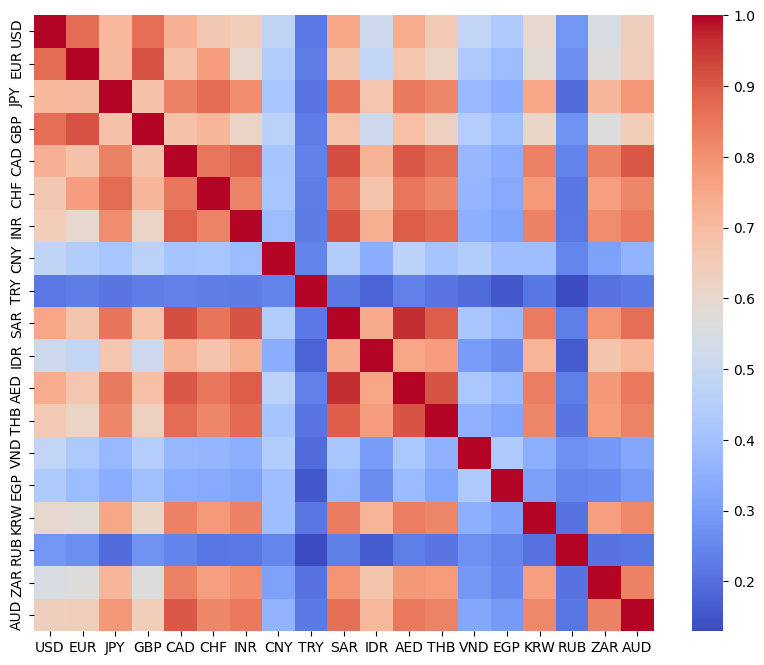

In [ ]:
#Visualize Correl
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [ ]:
#PCA
pca = PCA()
components = pca.fit_transform(returns_scaled)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.61324231 0.08763719 0.04945643 0.0457762  0.04240817 0.03152818
 0.02854283 0.01947829 0.01610283 0.01458911 0.01126994 0.00840658
 0.00759145 0.00642791 0.00553106 0.00464196 0.00377516 0.00197565
 0.00161875]


In [ ]:
#Examine PCA
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(currency_cols))],
    index=currency_cols
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
USD,0.238979,0.248742,-0.280558,-0.198328,0.107655,0.024897,0.009991,0.159883,-0.197073,-0.439381,-0.158433,-0.035687,0.296603,-0.101622,-0.139791,-0.255508,-0.167876,-0.474058,-0.175471
EUR,0.233588,0.234141,-0.328580,-0.304523,0.211666,0.031963,-0.021445,0.035161,0.172469,0.195580,0.039380,-0.019727,-0.135502,-0.074872,-0.152018,-0.297070,-0.317733,0.571493,0.097843
JPY,0.261439,-0.065594,-0.075041,-0.057292,-0.013082,0.013073,-0.013273,-0.117681,-0.413947,0.473510,-0.077739,0.011899,0.621514,0.081839,0.294563,0.093668,0.007446,0.116812,-0.009941
GBP,0.234638,0.242526,-0.304572,-0.272156,0.185146,0.010318,-0.021112,0.138539,0.228012,-0.057466,0.133145,-0.060159,-0.143758,0.148095,0.370274,0.492699,0.385644,-0.111946,0.070162
CAD,0.275522,-0.119371,0.017622,0.024389,0.031311,0.025957,0.011158,-0.134773,-0.021531,-0.190066,-0.155696,0.288448,0.021901,-0.049302,-0.122304,-0.362814,0.734504,0.236017,-0.016001


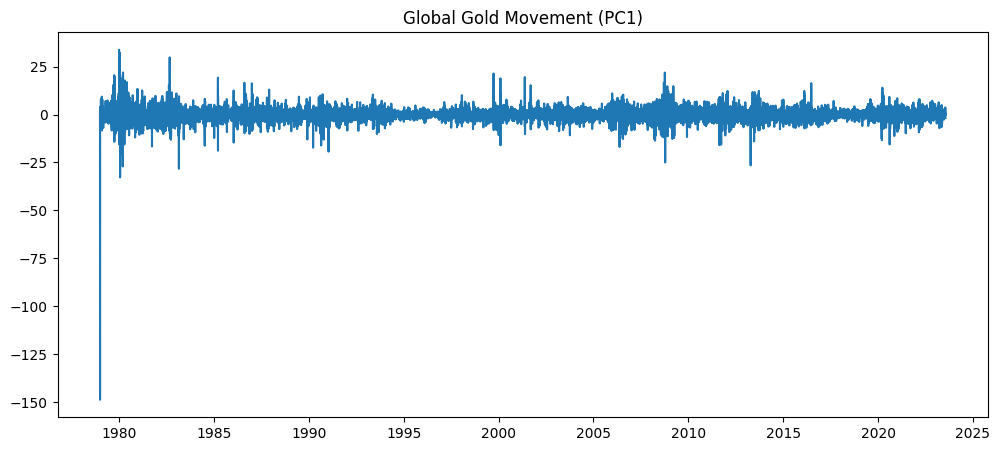

In [ ]:
#Plot First Principal Component Over Time
pc1_series = components[:, 0]

plt.figure(figsize=(12,5))
plt.plot(df['Date'].iloc[1:], pc1_series)
plt.title("Global Gold Movement (PC1)")
plt.show()

In [ ]:
#----------PHASE 3------------------

In [ ]:
# STEP 1: SELECT NUMBER OF PCs

cum_var = np.cumsum(pca.explained_variance_ratio_)

k = np.argmax(cum_var >= 0.90) + 1

print(f"Selected number of PCs: {k}")
print(f"Cumulative explained variance: {cum_var[k-1]:.4f}")

Selected number of PCs: 8
Cumulative explained variance: 0.9181


In [ ]:
# STEP 2: CREATE PCA DATASET

PC_df = pd.DataFrame(
    components[:, :k],
    columns=[f'PC{i+1}' for i in range(k)]
)

In [ ]:
# STEP 3: FEATURE ENGINEERING

# Lag features
for i in range(1, k+1):
    PC_df[f'PC{i}_lag1'] = PC_df[f'PC{i}'].shift(1)
    PC_df[f'PC{i}_lag7'] = PC_df[f'PC{i}'].shift(7)

# Rolling features
PC_df['PC1_MA7'] = PC_df['PC1'].rolling(7).mean()
PC_df['PC1_VOL7'] = PC_df['PC1'].rolling(7).std()

# Drop NaN
PC_df = PC_df.dropna().reset_index(drop=True)

In [ ]:
# STEP 4: CREATE X & y


X = PC_df.drop(columns=['PC1'])
y = PC_df['PC1']

print("Final Dataset Shape:", PC_df.shape)

Final Dataset Shape: (11618, 26)


In [ ]:
# STEP 5: TRAIN TEST SPLIT (TIME SERIES)

split = int(len(PC_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
# STEP 6: MODEL TRAINING

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=300, random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [ ]:
# STEP 7: MODEL EVALUATION

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

evaluate(y_test, pred_lr, "Linear Regression")
evaluate(y_test, pred_rf, "Random Forest")
evaluate(y_test, pred_gb, "Gradient Boosting")

Linear Regression: RMSE = 1.7550, R² = 0.4455
Random Forest: RMSE = 1.3241, R² = 0.6843
Gradient Boosting: RMSE = 1.4749, R² = 0.6083


In [ ]:
#MAE MSE RMSE

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    r2 = metrics.r2_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    print(f"{model_name}: RMSE = {rmse:.4f}, R² = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}")

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

evaluate(y_test, pred_lr, "Linear Regression")
evaluate(y_test, pred_rf, "Random Forest")
evaluate(y_test, pred_gb, "Gradient Boosting")

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, pred_lr))
rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, pred_rf))
rmse_gb = np.sqrt(metrics.mean_squared_error(y_test, pred_gb))

r2_lr = metrics.r2_score(y_test, pred_lr)
r2_rf = metrics.r2_score(y_test, pred_rf)
r2_gb = metrics.r2_score(y_test, pred_gb)

mae_lr = metrics.mean_absolute_error(y_test, pred_lr)
mae_rf = metrics.mean_absolute_error(y_test, pred_rf)
mae_gb = metrics.mean_absolute_error(y_test, pred_gb)

mse_lr = metrics.mean_squared_error(y_test, pred_lr)
mse_rf = metrics.mean_squared_error(y_test, pred_rf)
mse_gb = metrics.mean_squared_error(y_test, pred_gb)

Linear Regression: RMSE = 1.7550, R² = 0.4455, MAE = 1.2858, MSE = 3.0799
Random Forest: RMSE = 1.3241, R² = 0.6843, MAE = 0.8774, MSE = 1.7533
Gradient Boosting: RMSE = 1.4749, R² = 0.6083, MAE = 1.0240, MSE = 2.1755


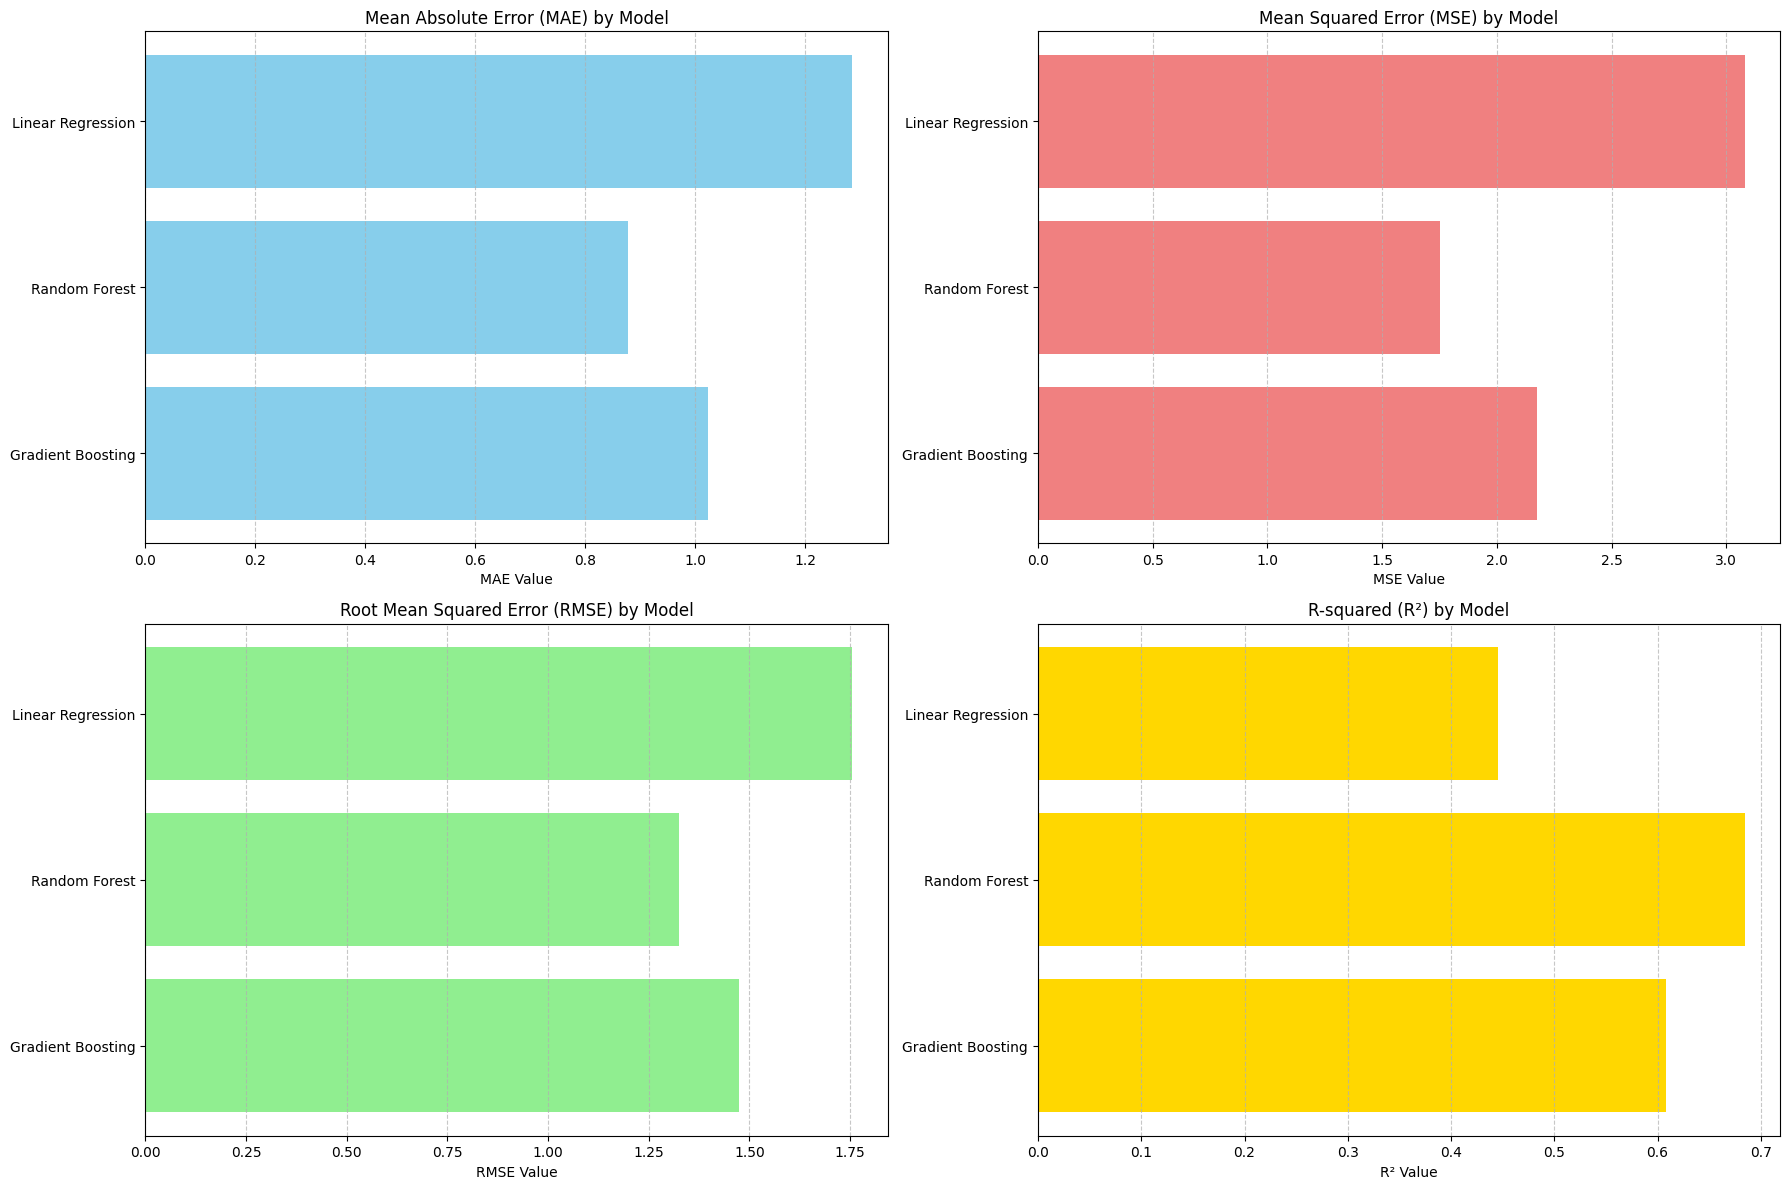

In [ ]:
#Visualize Metrics

import matplotlib.pyplot as plt
import numpy as np


models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
mae_values = [mae_lr, mae_rf, mae_gb]
mse_values = [mse_lr, mse_rf, mse_gb]
rmse_values = [rmse_lr, rmse_rf, rmse_gb]
r2_values = [r2_lr, r2_rf, r2_gb]

y_pos = np.arange(len(models))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

axes[0].barh(y_pos, mae_values, align='center', color='skyblue')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
axes[0].invert_yaxis()
axes[0].set_xlabel('MAE Value')
axes[0].set_title('Mean Absolute Error (MAE) by Model')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

axes[1].barh(y_pos, mse_values, align='center', color='lightcoral')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(models)
axes[1].invert_yaxis()
axes[1].set_xlabel('MSE Value')
axes[1].set_title('Mean Squared Error (MSE) by Model')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

axes[2].barh(y_pos, rmse_values, align='center', color='lightgreen')
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(models)
axes[2].invert_yaxis()
axes[2].set_xlabel('RMSE Value')
axes[2].set_title('Root Mean Squared Error (RMSE) by Model')
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

axes[3].barh(y_pos, r2_values, align='center', color='gold')
axes[3].set_yticks(y_pos)
axes[3].set_yticklabels(models)
axes[3].invert_yaxis()
axes[3].set_xlabel('R² Value')
axes[3].set_title('R-squared (R²) by Model')
axes[3].grid(axis='x', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# STEP 8: CROSS VALIDATION

cv_scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='r2')
print("Cross-validation R² (RF):", cv_scores.mean())

Cross-validation R² (RF): 0.511041616603628


In [ ]:
# STEP 9: FEATURE IMPORTANCE


importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:\n")
print(importance.head(10))


Top 10 Important Features:

PC2         0.259233
PC3         0.110997
PC1_MA7     0.110335
PC1_VOL7    0.091247
PC4         0.066715
PC7         0.062366
PC6         0.059815
PC5         0.040134
PC1_lag1    0.023261
PC2_lag1    0.021243
dtype: float64


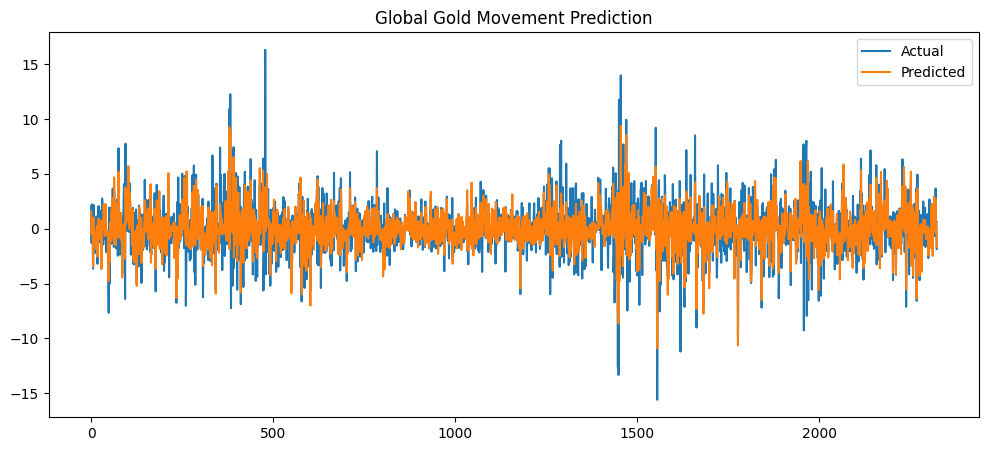

In [ ]:
# STEP 10: VISUALIZATION

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_gb, label="Predicted")
plt.title("Global Gold Movement Prediction")
plt.legend()
plt.show()

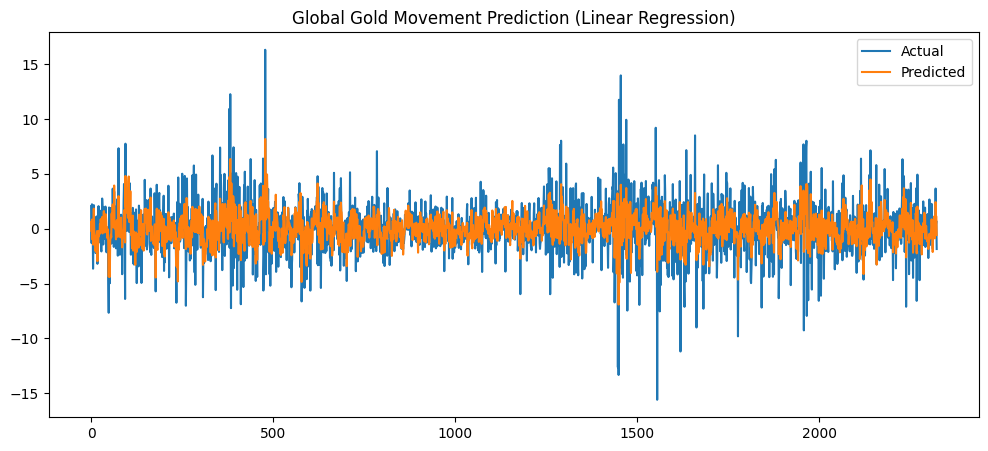

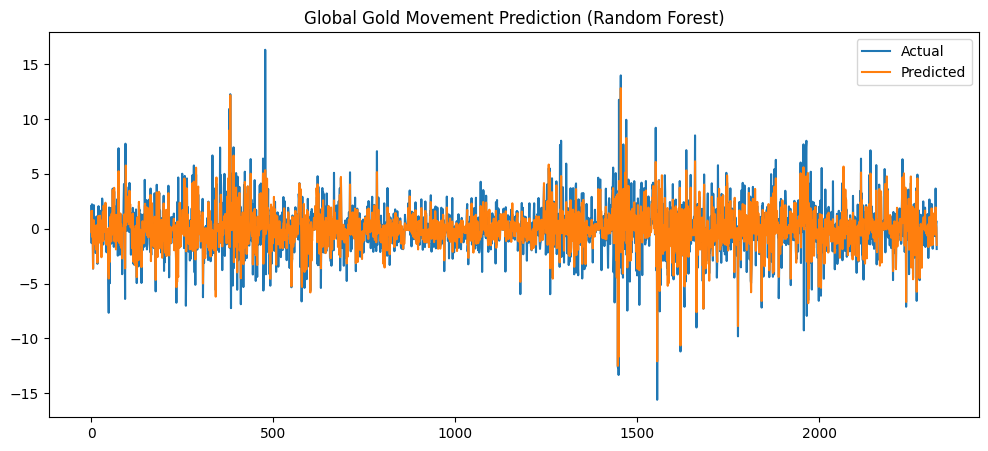

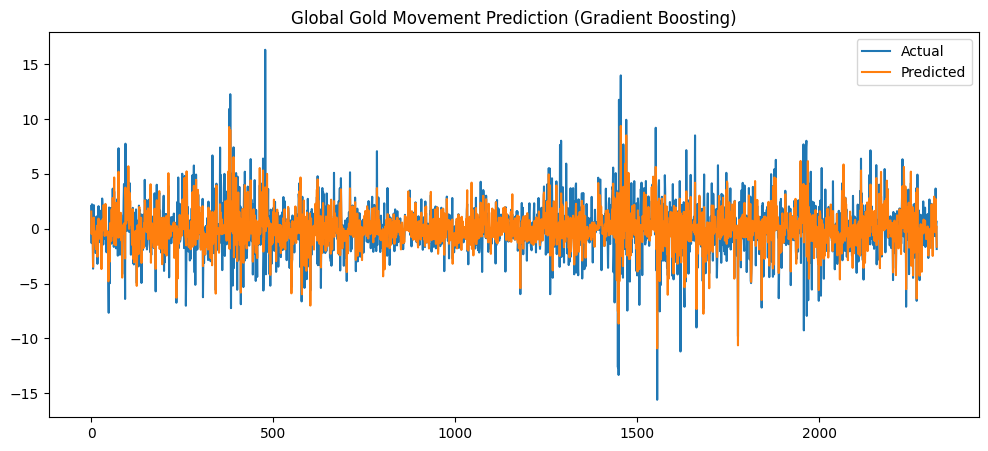

In [ ]:
#10 VisualizationD

import matplotlib.pyplot as plt

#Linear Regression
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_lr, label="Predicted")
plt.title("Global Gold Movement Prediction (Linear Regression)")
plt.legend()
plt.show()

#Random Forest
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_rf, label="Predicted")
plt.title("Global Gold Movement Prediction (Random Forest)")
plt.legend()
plt.show()

#Gradient Boosting
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_gb, label="Predicted")
plt.title("Global Gold Movement Prediction (Gradient Boosting)")
plt.legend()
plt.show()